SCENARIO 1 – BAGGING (Diabetes)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


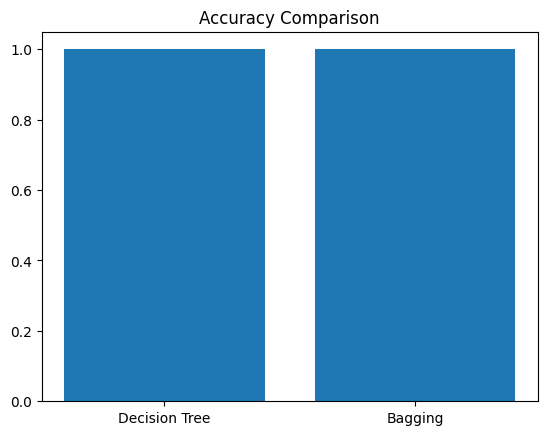

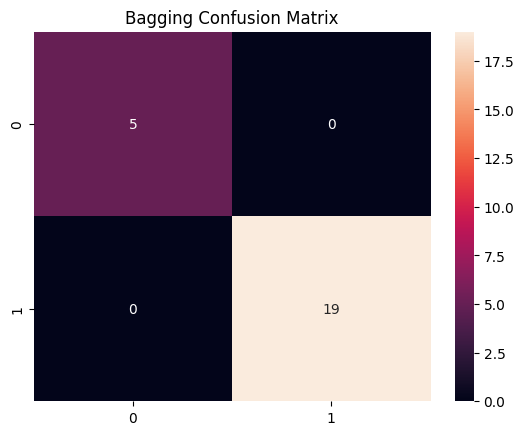

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Load dataset
df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Bar graph
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True)
plt.title("Bagging Confusion Matrix")
plt.show()